# Explore the structure of folders

In [1]:
%%bash
ls *

LICENSE
README.md
data_exploration.ipynb

Synthea_data:
synthea_sample_data_csv_100_latest
synthea_sample_data_csv_1K_nov2021

UCI_ML_data:
diabetes


In [2]:
%%bash
ls UCI_ML_data/

diabetes


In [3]:
%%bash
file -d UCI_ML_data/diabetes/

UCI_ML_data/diabetes/: directory


In [4]:
%%bash
ls -lsah UCI_ML_data/diabetes/

total 32
 0 drwx------@  6 jiz  staff   192B Dec  5 20:08 .
 0 drwxr-xr-x   4 jiz  staff   128B Dec  5 19:14 ..
16 -rw-r--r--@  1 jiz  staff   6.0K Dec  6 01:44 .DS_Store
 0 drwxr-xr-x@ 75 jiz  staff   2.3K Aug 27  1993 Diabetes-Data
 8 -rwx------@  1 jiz  staff   115B May 22  2023 Index
 8 -rwx------@  1 jiz  staff   682B May 22  2023 README


In [5]:
%%bash
ls -lh UCI_ML_data/diabetes/Diabetes-Data/

total 1600
-rw-r--r--@ 1 jiz  staff   1.7K Aug  6  1993 Data-Codes
-rw-r--r--@ 1 jiz  staff   6.1K Aug 27  1993 Domain-Description
-rw-r--r--@ 1 jiz  staff   2.5K Aug 27  1993 README-DIABETES
-rw-r--r--@ 1 jiz  staff    22K Aug  6  1993 data-01
-rw-r--r--@ 1 jiz  staff    18K Aug  6  1993 data-02
-rw-r--r--@ 1 jiz  staff   6.7K Aug  6  1993 data-03
-rw-r--r--@ 1 jiz  staff   6.7K Aug  6  1993 data-04
-rw-r--r--@ 1 jiz  staff   6.7K Aug  6  1993 data-05
-rw-r--r--@ 1 jiz  staff   3.5K Aug  6  1993 data-06
-rw-r--r--@ 1 jiz  staff   5.7K Aug  6  1993 data-07
-rw-r--r--@ 1 jiz  staff   4.0K Aug  6  1993 data-08
-rw-r--r--@ 1 jiz  staff   4.6K Aug  6  1993 data-09
-rw-r--r--@ 1 jiz  staff   5.8K Aug  6  1993 data-10
-rw-r--r--@ 1 jiz  staff   5.2K Aug  6  1993 data-11
-rw-r--r--@ 1 jiz  staff   6.6K Aug  6  1993 data-12
-rw-r--r--@ 1 jiz  staff   6.6K Aug  6  1993 data-13
-rw-r--r--@ 1 jiz  staff   5.1K Aug  6  1993 data-14
-rw-r--r--@ 1 jiz  staff   6.6K Aug  6  1993 data-15
-rw-r--r--@ 1

# Import the necessary libraries to examine the datasets

## Import the advanced libraries

In [4]:
import pandas as pd
#import numpy as np
import pyampute as imputor
#from gensim.models import KeyedVectors as GensimKeyedVecs # unsupervised semantic modeling from plain text
# to explore synonyms, hypernyms, and hyponyms
#from nltk.corpus import wordnet as NltkWordNet # linguistically-grounded approach finding the semantic relationships between words
import matplotlib.pyplot as plt

## Import the typing and data-time libraries

In [5]:
from typing import Dict, Any, List, Set, Union
from datetime import datetime

## Instructions on using the NLP-relaed libraries imported above

#### Example of using Gensim's KeyedVectors
```python
from gensim.models import KeyedVectors
model = KeyedVectors.load_word2vec_format('model_path', binary=True)
similarity = model.similarity('column_name_one', 'column_name_two')
```

#### Example of using NLTK's wordnet
```python
from nltk.corpus import wordnet as wn
word1 = wn.synsets('column_name_one')[0]  # Assuming the first synset
word2 = wn.synsets('column_name_two')[0]
similarity = word1.wup_similarity(word2)  # Wu-Palmer similarity
```

# Dataset exploration

## UCI diabetes dataset

In [19]:
%%bash
cat UCI_ML_data/diabetes/Diabetes-Data/README-DIABETES

The DIABETES data sets in this directory are provided for use in 1994 
AI in Medicine symposium submissions.  Permission is granted to use the
data sets for other research purposes as long as appropriate credit is
given as to the source (AIM-94 data set provided by Michael Kahn, MD, PhD, 
Washington University, St. Louis, MO).


Index:
------

* Data-Codes: a listing of the codes used in the data sets.

* Domain-Description: This file describes the basic physiology and patho-
physiology of diabetes mellitus and its treatment.

* data-[01-70]: data sets covering several weeks' to months' worth of
outpatient care on 70 patients.  An additional 10 sets will be made
available two weeks prior to the symposium for interested parties.  Please
contact the organizers if you would like to obtain these data sets.


Methods:
--------

You do not need to use all the data in order to participate.  Use any 
subset of the available data from either the ICU data set or the diabetes 
data set.  Furtherm

In [21]:
%%bash
cat UCI_ML_data/diabetes/Diabetes-Data/Data-Codes

Diabetes patient records were obtained from two sources:  an automatic
electronic recording device and paper records.  The automatic device
had an internal clock to timestamp events, whereas the paper records
only provided "logical time" slots (breakfast, lunch, dinner,
bedtime).  For paper records, fixed times were assigned to breakfast
(08:00), lunch (12:00), dinner (18:00), and bedtime (22:00).  Thus
paper records have fictitious uniform recording times whereas
electronic records have more realistic time stamps.

Diabetes files consist of four fields per record.  Each field is
separated by a tab and each record is separated by a newline.

File Names and format:
(1) Date in MM-DD-YYYY format
(2) Time in XX:YY format
(3) Code
(4) Value

The Code field is deciphered as follows:

33 = Regular insulin dose
34 = NPH insulin dose
35 = UltraLente insulin dose
48 = Unspecified blood glucose measurement
57 = Unspecified blood glucose measurement
58 = Pre-breakfast blood glucose measurement
59

In [22]:
# create the column names from the description above
diabetes_columns = ["Date", "Time", "Code", "Value"]

In [23]:
uci_diabetes_df1 = pd.read_csv("UCI_ML_data/diabetes/Diabetes-Data/data-01", sep="\t", names=diabetes_columns)
uci_diabetes_df2 = pd.read_csv("UCI_ML_data/diabetes/Diabetes-Data/data-02", sep="\t", names=diabetes_columns)

In [40]:
uci_diabetes_df1.head()

,Date,Time,Code,Value
0,04-21-1991,9:09,58,100
1,04-21-1991,9:09,33,9
2,04-21-1991,9:09,34,13
3,04-21-1991,17:08,62,119
4,04-21-1991,17:08,33,7


In [42]:
uci_diabetes_df1.tail()

,Date,Time,Code,Value
938,09-02-1991,17:30,33,7
939,09-02-1991,23:00,48,155
940,09-03-1991,7:20,58,110
941,09-03-1991,7:20,33,9
942,09-03-1991,7:20,34,16


In [41]:
uci_diabetes_df2.head()

,Date,Time,Code,Value
0,10-10-1989,08:00,58,149
1,10-10-1989,08:00,33,010
2,10-10-1989,12:00,60,116
3,10-10-1989,12:00,33,004
4,10-10-1989,18:00,62,304


In [72]:
uci_diabetes_df2.head()

,Date,Time,Code,Value
0,10-10-1989,08:00,58,149
1,10-10-1989,08:00,33,10
2,10-10-1989,12:00,60,116
3,10-10-1989,12:00,33,4
4,10-10-1989,18:00,62,304


In [43]:
uci_diabetes_df2.tail()

,Date,Time,Code,Value
756,01-12-1990,22:00,33,016
757,01-13-1990,08:00,58,272
758,01-13-1990,08:00,33,012
759,01-13-1990,12:00,60,388
760,01-13-1990,12:00,33,006


In [55]:
uci_diabetes_df1.dtypes

Date     object
Time     object
Code      int64
Value     int64
dtype: object

In [56]:
uci_diabetes_df2.dtypes

Date     object
Time     object
Code      int64
Value    object
dtype: object

change the datatype of columns in <code>uci_diabetes_df1</code> and <code>uci_diabetes_df2</code> before using <code>pandas.DataFrame.describe()</code>

In [61]:
uci_diabetes_df2["Value"]

0      149
1       10
2      116
3        4
4      304
      ... 
756     16
757    272
758     12
759    388
760      6
Name: Value, Length: 761, dtype: object

In [65]:
# change the datatype of columns in <code>uci_diabetes_df1</code> and <code>uci_diabetes_df2</code> before using DataFrame.describe()
for df in [uci_diabetes_df1, uci_diabetes_df2]:
    df["Code"] = df["Code"].astype("category")

uci_diabetes_df2["Value"] = uci_diabetes_df2["Value"].str.replace(r'^0+', '', regex=True)
uci_diabetes_df2["Value"] = uci_diabetes_df2["Value"].astype("int64") 

ValueError: invalid literal for int() with base 10: 'Hi'

Try to figure out the reason of the bug above

In [75]:
uci_diabetes_df2.tail() # check if the strings are correctly reformatted

,Date,Time,Code,Value
756,01-12-1990,22:00,33,16
757,01-13-1990,08:00,58,272
758,01-13-1990,08:00,33,12
759,01-13-1990,12:00,60,388
760,01-13-1990,12:00,33,6


In [70]:
all_digits = uci_diabetes_df2['Value'].astype(str).str.isdigit().all()
all_digits # check if non-digit values are present in this column

False

In [69]:
uci_diabetes_df1.describe()

,Value
count,943.000000
mean,67.410392
std,85.617268
min,0.000000
25%,7.000000
50%,15.000000
75%,122.000000
max,343.000000


In [68]:
uci_diabetes_df2.describe()

,Date,Time,Code,Value
count,761,761,761,761
unique,96,4,6,225
top,10-27-1989,08:00,33,10
freq,9,193,378,143


<b>Conclusions</b>: <br>
From the data exmamination above, we could see that the UCI diabetes is a time-series data consisting of four columns only. It cannot be seriously considered as electronic health records (EHR). Therefore, it shall be only considered as a potential benchmark when compared to other existing algorithms. To justify our adoption of federated learning for imputation, we shall use the data source of proper EHRs and then create/construct a trainable and testable pandas dataframe. <br>
Therefore, let's put off the experiements on the UCI diabetes dataset for the moment

<hr/>

## Research on the Synthea dataset

### Check the names of sheets

In [27]:
%%bash
ls Synthea_data/synthea_sample_data_csv_1K_nov2021/

allergies.csv
careplans.csv
claims.csv
claims_transactions.csv
conditions.csv
devices.csv
encounters.csv
imaging_studies.csv
immunizations.csv
medications.csv
observations.csv
organizations.csv
patients.csv
payer_transitions.csv
payers.csv
procedures.csv
providers.csv
supplies.csv


In [30]:
%%bash
ls Synthea_data/synthea_sample_data_csv_1K_nov2021/ | wc -l # check the number of CSV files/subsheets of the dataset

      18


### First of all, investigate the sheet of patients

#### Read the sheet and check its metadata

In [6]:
synthea_1k_patients_df = pd.read_csv("Synthea_data/synthea_sample_data_csv_1K_nov2021/patients.csv")

In [392]:
synthea_1k_patients_df.dtypes

Id                      object
BIRTHDATE               object
DEATHDATE               object
SSN                     object
DRIVERS                 object
PASSPORT                object
PREFIX                  object
FIRST                   object
LAST                    object
SUFFIX                  object
MAIDEN                  object
MARITAL                 object
RACE                    object
ETHNICITY               object
GENDER                  object
BIRTHPLACE              object
ADDRESS                 object
CITY                    object
STATE                   object
COUNTY                  object
ZIP                    float64
LAT                    float64
LON                    float64
HEALTHCARE_EXPENSES    float64
HEALTHCARE_COVERAGE    float64
dtype: object

In [390]:
synthea_1k_patients_df.describe()

,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
count,618.000000,1163.000000,1163.000000,1.163000e+03,1.163000e+03
mean,2001.263754,42.255261,-71.336063,1.256248e+06,1.717684e+05
std,443.449141,0.286969,0.618013,1.148747e+06,4.885749e+05
min,1001.000000,41.299942,-73.445165,8.259920e+02,0.000000e+00
25%,1835.000000,42.100121,-71.516412,4.426256e+05,1.293600e+03
50%,2118.500000,42.307061,-71.140665,1.142154e+06,1.747219e+04
75%,2190.000000,42.448367,-71.004105,1.900910e+06,2.051068e+05
max,2861.000000,42.888532,-69.978831,2.311655e+07,1.356228e+07


#### Examine the actual data of this sheet

##### Take a first look of the data

In [38]:
synthea_1k_patients_df.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-02-17,NaN,999-65-3251,NaN,NaN,NaN,Damon455,Langosh790,NaN,...,Middleborough Massachusetts US,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,NaN,999-49-3323,S99941126,NaN,NaN,Thi53,Wunsch504,NaN,...,Danvers Massachusetts US,972 Tillman Branch Suite 48,Bellingham,Massachusetts,Norfolk County,NaN,42.035213,-71.482519,402723.4150,14064.1350
2,339144f8-50e1-633e-a013-f361391c4cff,1998-05-11,NaN,999-10-8743,S99996708,X75063318X,Mr.,Chi716,Greenfelder433,NaN,...,Athens Athens Prefecture GR,1060 Bernhard Crossroad Suite 15,Boston,Massachusetts,Suffolk County,2131.0,42.292557,-71.061160,571935.8725,787.5375
3,d488232e-bf14-4bed-08c0-a82f34b6a197,2003-01-28,NaN,999-56-6057,S99929424,NaN,Ms.,Phillis443,Walter473,NaN,...,Boston Massachusetts US,677 Ritchie Terrace,Hingham,Massachusetts,Plymouth County,2043.0,42.200491,-70.916076,582557.8030,104782.2070
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,1993-12-23,NaN,999-91-4320,S99991143,X44132498X,Mr.,Jerrold404,Herzog843,NaN,...,Boston Massachusetts US,276 Bernier Branch,Revere,Massachusetts,Suffolk County,NaN,42.381875,-70.999286,475826.8550,18067.0950


##### Check the column names (<b>We aim at making a simplified <code>patient_df</code> dataframe to exclude the unnecessary columns</b>)

In [78]:
patient_cols = list(synthea_1k_patients_df.columns)
patient_cols

['Id',
 'BIRTHDATE',
 'DEATHDATE',
 'SSN',
 'DRIVERS',
 'PASSPORT',
 'PREFIX',
 'FIRST',
 'LAST',
 'SUFFIX',
 'MAIDEN',
 'MARITAL',
 'RACE',
 'ETHNICITY',
 'GENDER',
 'BIRTHPLACE',
 'ADDRESS',
 'CITY',
 'STATE',
 'COUNTY',
 'ZIP',
 'LAT',
 'LON',
 'HEALTHCARE_EXPENSES',
 'HEALTHCARE_COVERAGE']

##### Check the ID-related columns

To check if Id and SSN are mutually replacable. Therefore, let's just use anonymized IDs instead of privacy-sensitive SSNs

In [190]:
UNIQUE_IDS = pd.unique(synthea_1k_patients_df["Id"]).shape[0]
UNIQUE_SSNS = pd.unique(synthea_1k_patients_df["SSN"]).shape[0]
UNIQUE_IDS == UNIQUE_SSNS

True

<b>Conclusions:</b> Yes, these two attributes are mutually replacable

##### Check the "GENDER" column

In [163]:
synthea_1k_patients_df["GENDER"] = synthea_1k_patients_df["GENDER"].astype("category")

In [178]:
pd.unique(synthea_1k_patients_df["GENDER"])

['M', 'F']
Categories (2, object): ['F', 'M']

In [214]:
pd.unique(synthea_1k_patients_df["Id"][synthea_1k_patients_df["GENDER"] == "M"]).shape[0]

547

In [215]:
pd.unique(synthea_1k_patients_df["Id"][synthea_1k_patients_df["GENDER"] == "F"]).shape[0]

616

<b>Stats</b>: 1163 patients, including 547 Males and 616 Females

##### Check the difference between <code>RACE</code> and <code>ETHNICITY</code>, which seem to be ambiguous

In [157]:
pd.unique(synthea_1k_patients_df["RACE"])

array(['white', 'black', 'asian', 'hawaiian', 'other', 'native'],
      dtype=object)

In [216]:
for race in pd.unique(synthea_1k_patients_df["RACE"]):
    num = pd.unique(synthea_1k_patients_df["Id"][synthea_1k_patients_df["RACE"] == race]).shape[0]
    print(f"Race \"{race}\": {num} patients")

Race "white": 963 patients
Race "black": 96 patients
Race "asian": 73 patients
Race "hawaiian": 18 patients
Race "other": 11 patients
Race "native": 2 patients


Show the distribution of the races

In [158]:
pd.unique(synthea_1k_patients_df["ETHNICITY"])

array(['nonhispanic', 'hispanic'], dtype=object)

Show the distribution of the ethnicities

In [217]:
for ethnicity in pd.unique(synthea_1k_patients_df["ETHNICITY"]):
    num = pd.unique(synthea_1k_patients_df["Id"][synthea_1k_patients_df["ETHNICITY"] == ethnicity]).shape[0]
    print(f"Ethnicity \"{ethnicity}\": {num} patients")

Ethnicity "nonhispanic": 1058 patients
Ethnicity "hispanic": 105 patients


Therefore, let's investigate the races of non-Hispianic and Hispanic patients respectively

In [218]:
HISPANIC_RACES = list(pd.unique(synthea_1k_patients_df["RACE"][synthea_1k_patients_df["ETHNICITY"]=="hispanic"]))
set(HISPANIC_RACES)

{'asian', 'black', 'hawaiian', 'other', 'white'}

In [219]:
NON_HISPANIC_RACES = list(pd.unique(synthea_1k_patients_df["RACE"][synthea_1k_patients_df["ETHNICITY"]=="nonhispanic"]))
set(NON_HISPANIC_RACES)

{'asian', 'black', 'hawaiian', 'native', 'other', 'white'}

In [220]:
for race in pd.unique(synthea_1k_patients_df["RACE"]):
    for ethnicity in pd.unique(synthea_1k_patients_df["ETHNICITY"]):
        num = pd.unique(synthea_1k_patients_df["Id"][(synthea_1k_patients_df["RACE"] == race) & (synthea_1k_patients_df["ETHNICITY"] == ethnicity)]).shape[0]
        print(f"{ethnicity} {race}: {num} patients")

nonhispanic white: 879 patients
hispanic white: 84 patients
nonhispanic black: 82 patients
hispanic black: 14 patients
nonhispanic asian: 69 patients
hispanic asian: 4 patients
nonhispanic hawaiian: 17 patients
hispanic hawaiian: 1 patients
nonhispanic other: 9 patients
hispanic other: 2 patients
nonhispanic native: 2 patients
hispanic native: 0 patients


<b>Question:</b> how to correctly categorize the races of the patients? Shall I classify their races more accurately? 

Therefore, let's investigate the birthplace of these patients

##### Check the <code>BIRTHPLACE</code> of the patients

In [206]:
pd.unique(synthea_1k_patients_df.BIRTHPLACE).shape[0] # check the number of unique birthplaces among the 1163 patients

317

In [324]:
pd.unique(synthea_1k_patients_df.BIRTHPLACE)[:10]

array(['Middleborough  Massachusetts  US', 'Danvers  Massachusetts  US',
       'Athens  Athens Prefecture  GR', 'Boston  Massachusetts  US',
       'Northborough  Massachusetts  US', 'Bogota  Bogota  CO',
       'Merrimac  Massachusetts  US', 'Northbridge  Massachusetts  US',
       'East Longmeadow  Massachusetts  US', 'Mashpee  Massachusetts  US'],
      dtype=object)

We may see that there are patients born outside the US, such as in Greece or Columbia

let's check how many countries there are among in the country of birth of the patients

In [326]:
'East Longmeadow  Massachusetts  US'.split("  ")

['East Longmeadow', 'Massachusetts', 'US']

In [327]:
'East Longmeadow  Massachusetts  US'.split("  ")[2]

'US'

In [328]:
BIRTH_COUNTRY_LIST = list(synthea_1k_patients_df.BIRTHPLACE.apply(lambda x: x.split("  ")[2]))
BIRTH_COUNTRY_SET = set(BIRTH_COUNTRY_LIST)
BIRTH_COUNTRY_SET

{'AR',
 'CN',
 'CO',
 'CU',
 'DE',
 'DM',
 'DO',
 'FR',
 'GR',
 'GT',
 'HN',
 'HT',
 'IN',
 'IT',
 'JM',
 'JP',
 'KR',
 'MX',
 'PA',
 'PE',
 'PR',
 'RU',
 'SA',
 'US',
 'VN'}

<b>Full name of the countries from the abbreviations</b>:
AR: Argentina <br/>
CN: China <br/>
CO: Colombia <br/>
CU: Cuba <br/>
DE: Germany <br/>
DM: Dominica <br/>
DO: Dominican Republic <br/>
FR: France <br/>
GR: Greece <br/>
GT: Guatemala <br/>
HN: Honduras <br/>
HT: Haiti <br/>
IN: India <br/>
IT: Italy <br/>
JM: Jamaica <br/>
JP: Japan <br/>
KR: Korea, Republic of <br/>
MX: Mexico <br/>
PA: Panama <br/>
PE: Peru <br/>
PR: Puerto Rico <br/>
RU: Russian Federation <br/>
SA: Saudi Arabia <br/>
US: United States <br/>
VN: Viet Nam

It might make sense to seperate <code>Asians</code> above into South Asians and East Asians depending on whether a patient was born in India?

In [331]:
BORN_COUNTRY_FREQ_DICT: Dict[str, int] = dict()
for country in BIRTH_COUNTRY_LIST:
    if country not in BORN_COUNTRY_FREQ_DICT:
        BORN_COUNTRY_FREQ_DICT[country] = 1
    else:
        BORN_COUNTRY_FREQ_DICT[country] += 1

In [332]:
BORN_COUNTRY_FREQ_DICT

{'US': 1064,
 'GR': 2,
 'CO': 4,
 'PE': 4,
 'DO': 3,
 'CN': 12,
 'DM': 17,
 'CU': 2,
 'MX': 8,
 'PR': 10,
 'IN': 6,
 'VN': 7,
 'RU': 3,
 'FR': 2,
 'AR': 2,
 'IT': 4,
 'KR': 1,
 'HT': 2,
 'PA': 1,
 'DE': 4,
 'JP': 1,
 'SA': 1,
 'JM': 1,
 'GT': 1,
 'HN': 1}

In [352]:
synthea_1k_patients_df[["BIRTHDATE", "GENDER", "RACE", "ETHNICITY"]].loc[synthea_1k_patients_df.BIRTHPLACE.str.endswith(" IN")]

,BIRTHDATE,GENDER,RACE,ETHNICITY
111,1981-11-16,F,asian,nonhispanic
256,1928-11-13,F,asian,nonhispanic
284,1928-11-13,F,asian,nonhispanic
301,1928-11-13,F,asian,nonhispanic
320,1928-11-13,F,asian,nonhispanic
608,1963-12-05,M,asian,nonhispanic


Check the number of US-born Asians

In [349]:
synthea_1k_patients_df[["BIRTHDATE", "GENDER", "RACE", "ETHNICITY"]]\
.loc[(synthea_1k_patients_df.RACE == "asian") & (synthea_1k_patients_df.BIRTHPLACE.str.endswith(" US"))].head()

,BIRTHDATE,GENDER,RACE,ETHNICITY
18,2008-11-09,F,asian,nonhispanic
31,2007-06-22,M,asian,nonhispanic
55,2010-11-27,F,asian,hispanic
95,1971-01-03,M,asian,nonhispanic
130,2016-08-08,M,asian,nonhispanic


In [350]:
synthea_1k_patients_df[["BIRTHDATE", "GENDER", "RACE", "ETHNICITY"]]\
.loc[(synthea_1k_patients_df.RACE == "asian") & (synthea_1k_patients_df.BIRTHPLACE.str.endswith(" US"))].shape[0]

45

There is a large number of US-born Asians, therefore, it doesn't make sense for us to exclude them

##### Check the <code>HEALTHCARE_EXPENSES</code> and <code>HEALTHCARE_COVERAGE</code> column of the patients

First of all, check if the <code>HEALTHCARE_EXPENSES</code> are always larger than the <code>HEALTHCARE_COVERAGE</code>

In [333]:
synthea_1k_patients_df.loc[synthea_1k_patients_df.HEALTHCARE_EXPENSES >= synthea_1k_patients_df.HEALTHCARE_COVERAGE].shape

(1127, 25)

Therefore, it's not always necessarily the case. Let's check the patients whose healthcare coverage exceeds the healthcare expenses

In [353]:
synthea_1k_patients_df.loc[synthea_1k_patients_df.HEALTHCARE_EXPENSES < synthea_1k_patients_df.HEALTHCARE_COVERAGE].shape

(36, 25)

In [355]:
synthea_1k_patients_df.loc[synthea_1k_patients_df.HEALTHCARE_EXPENSES < synthea_1k_patients_df.HEALTHCARE_COVERAGE].head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
36,060e72d3-912e-55cd-0c92-5faa6cb7a6db,1969-01-03,NaN,999-66-6825,S99931952,X14008939X,Mr.,Benny518,Tillman293,NaN,...,Medford Massachusetts US,941 Rodriguez Trace Suite 61,Quincy,Massachusetts,Norfolk County,2169.0,42.240058,-70.987747,1.816518e+05,2.629950e+05
60,6b3a5686-0f63-5ce4-cc03-0bba2052f7b1,1958-10-28,NaN,999-96-8207,S99914224,X43330625X,Mrs.,Lashawnda573,O'Hara248,NaN,...,Deerfield Massachusetts US,230 Robel Drive Suite 95,Lowell,Massachusetts,Middlesex County,1851.0,42.631653,-71.373444,1.210508e+06,1.210784e+06
63,50aac3ff-d836-adfd-620d-662fa08fdf55,1960-09-23,NaN,999-39-5007,S99928200,X13955983X,Mrs.,Jacquelynn434,Morar593,NaN,...,Cambridge Massachusetts US,638 Hamill Orchard,Holyoke,Massachusetts,Hampden County,NaN,42.183676,-72.610970,5.152295e+05,1.361113e+06
88,251ec304-b5fb-e3fa-72ed-197b957c3378,2020-05-13,NaN,999-74-4099,NaN,NaN,NaN,Harris789,Torphy630,NaN,...,Fall River Massachusetts US,380 Gibson Street Unit 30,Haverhill,Massachusetts,Essex County,NaN,42.798938,-71.154481,5.147439e+03,6.411331e+03
120,d432ac90-2b10-097f-9a30-093555da284f,1970-08-20,NaN,999-64-3099,S99989688,X32934785X,Mrs.,Esther279,Toy286,NaN,...,Andover Massachusetts US,931 Herman Vale Unit 62,Middleborough Center,Massachusetts,Plymouth County,NaN,41.910991,-70.893990,6.383235e+05,6.497223e+05


Plot the distribution of <code>HEALTHCARE_EXPENSES</code>

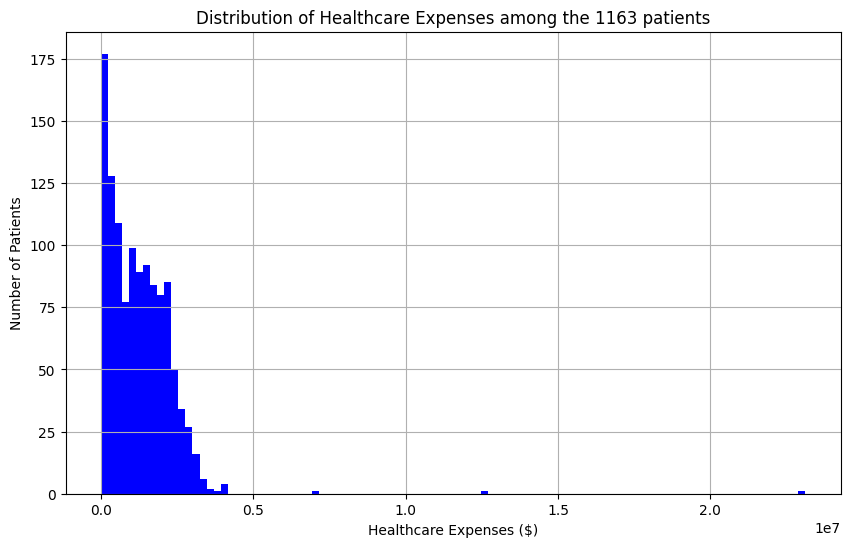

In [365]:
plt.figure(figsize=(10, 6))
plt.hist(synthea_1k_patients_df.HEALTHCARE_EXPENSES, bins=100, color='blue')
plt.title('Distribution of Healthcare Expenses among the 1163 patients')
plt.xlabel('Healthcare Expenses ($)')
plt.ylabel('Number of Patients')

# Show the plot
plt.grid(True)
plt.show()

Plot the distribution of <code>HEALTHCARE_COVERAGE</code>

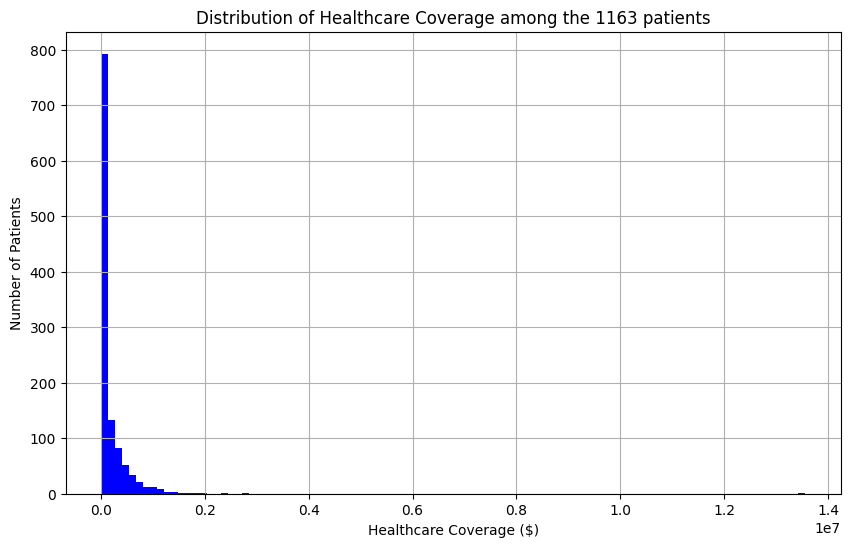

In [366]:
plt.figure(figsize=(10, 6))
plt.hist(synthea_1k_patients_df.HEALTHCARE_COVERAGE, bins=100, color='blue')
plt.title('Distribution of Healthcare Coverage among the 1163 patients')
plt.xlabel('Healthcare Coverage ($)')
plt.ylabel('Number of Patients')

# Show the plot
plt.grid(True)
plt.show()

##### Check the <code>BIRTHDATE</code> and <code>DEATHDATE</code> of the patients

Check the number of alive and deceased patients

In [322]:
synthea_1k_patients_df[synthea_1k_patients_df["DEATHDATE"].notna()].shape[0]

163

In [321]:
synthea_1k_patients_df[synthea_1k_patients_df["DEATHDATE"].isna()].shape[0]

1000

In [253]:
synthea_1k_patients_df[synthea_1k_patients_df.DEATHDATE.notna()].head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
14,55a6a46e-a1a4-0298-e58f-c0cb27cbb022,1958-09-18,2009-11-13,999-79-5115,S99956983,X26820988X,Mrs.,Maddie576,Gutmann970,NaN,...,Boston Massachusetts US,577 Schmeler Frontage road Unit 7,Quincy,Massachusetts,Norfolk County,2169.0,42.314702,-71.027005,2.895618e+06,312276.3060
27,7024858b-f5e2-efee-8e2f-67f503fef6a5,1969-01-03,1997-02-17,999-91-3005,S99927148,X79375706X,Mrs.,Rosalia943,Klocko335,NaN,...,Boston Massachusetts US,898 Wisoky Green,Lynn,Massachusetts,Essex County,1906.0,42.506104,-70.925543,6.862768e+05,24752.2350
58,04f25f73-04b2-469c-3806-540417a0d61c,1969-10-19,2005-11-09,999-93-4258,S99913030,X20390688X,Mrs.,Maye976,Dickinson688,NaN,...,Plymouth Massachusetts US,392 Renner Divide Suite 57,Woburn,Massachusetts,Middlesex County,NaN,42.478472,-71.162145,2.815497e+06,7908.8925
70,9ac43dbb-44d6-871e-b411-a1c18c61b55e,1942-10-15,1996-05-12,999-38-2466,S99958981,X3498799X,Mr.,Mohammad578,Mann644,NaN,...,Marblehead Massachusetts US,730 Kessler Common Unit 54,Pembroke,Massachusetts,Plymouth County,NaN,42.018233,-70.789028,1.483250e+06,1904.7225
73,10a1709a-5dde-1e3a-4c06-d8de03764712,1958-04-07,2011-07-10,999-81-4359,S99921632,X77153984X,Mr.,Werner409,Schneider199,NaN,...,Auburn Massachusetts US,474 Koelpin Street Suite 44,Yarmouth,Massachusetts,Barnstable County,NaN,41.660430,-70.226336,2.381577e+06,16500.7875


<b>Conclusions</b>: <br/>
1. 1000 alive patients, and 163 deceased patients
2. <code>BIRTHDATE</code> and <code>DEATHDATE</code> are both in the format <code>yyyy-mm-dd</code> 

#### Perform data engineering to construct new columns

##### Create a new column <code>VITAL_STATUS</code> based on <code>BIRTHDATE</code> and <code>DEATHDATE</code>

In [12]:
synthea_1k_patients_alive_list: List[bool] = []

In [13]:
synthea_1k_patients_df[["Id", "BIRTHDATE", "DEATHDATE"]]\
.apply(
    lambda row: 
       synthea_1k_patients_alive_list.append(False if pd.notna(row.DEATHDATE) else True), 
    axis=1)

0       None
1       None
2       None
3       None
4       None
        ... 
1158    None
1159    None
1160    None
1161    None
1162    None
Length: 1163, dtype: object

In [14]:
synthea_1k_patients_alive_series = pd.Series(synthea_1k_patients_alive_list, dtype="boolean")

In [15]:
synthea_1k_patients_alive_series

0       True
1       True
2       True
3       True
4       True
        ... 
1158    True
1159    True
1160    True
1161    True
1162    True
Length: 1163, dtype: boolean

In [16]:
synthea_1k_patients_alive_series[synthea_1k_patients_alive_series==False]

14      False
27      False
58      False
70      False
73      False
        ...  
1092    False
1096    False
1134    False
1147    False
1157    False
Length: 163, dtype: boolean

##### Crete a new column <code>LIFESPAN</code> for the deceased patients

In [17]:
# create a python function calculating the lifespan of a deceased patient
def calculate_lifespan(birth_date: str, deceased_date: str) -> int:
    # Convert the string dates to datetime objects
    birth_datetime = datetime.strptime(birth_date, "%Y-%m-%d")
    deceased_datetime = datetime.strptime(deceased_date, "%Y-%m-%d")
    
    # Calculate the difference in days between the death and birth
    days_difference = (deceased_datetime - birth_datetime).days
    
    # Convert days to years (1 year = 365.25 days to account for leap years)
    years_difference = days_difference / 365.25
    
    # Round the years difference to the nearest integer with the specified rounding method
    rounded_years = int(years_difference + 0.5)  # This rounds up from .50
    
    return rounded_years

In [18]:
synthea_1k_patients_lifespan_list: List[Union[pd.NA, int]] = []
synthea_1k_patients_df[["Id", "BIRTHDATE", "DEATHDATE"]]\
.apply(
    lambda row: 
       synthea_1k_patients_lifespan_list.append(calculate_lifespan(row.BIRTHDATE, row.DEATHDATE) if pd.notna(row.DEATHDATE) else pd.NA), 
    axis=1)

0       None
1       None
2       None
3       None
4       None
        ... 
1158    None
1159    None
1160    None
1161    None
1162    None
Length: 1163, dtype: object

In [19]:
synthea_1k_patients_lifespan_series = pd.Series(synthea_1k_patients_lifespan_list, dtype="category")
synthea_1k_patients_lifespan_series

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1158    NaN
1159    NaN
1160    NaN
1161    NaN
1162    NaN
Length: 1163, dtype: category
Categories (77, int64): [1, 2, 5, 10, ..., 97, 99, 100, 103]

In [373]:
synthea_1k_patients_lifespan_series[synthea_1k_patients_lifespan_series.notna()]

14      51
27      28
58      36
70      54
73      53
        ..
1092    55
1096    89
1134    76
1147    23
1157    39
Length: 163, dtype: category
Categories (77, int64): [1, 2, 5, 10, ..., 97, 99, 100, 103]

##### Crete a new column <code>AGE</code> for the alive patients

In [20]:
# create a python function calculating the lifespan of a deceased patient
def calculate_age(birth_date: str, ehr_creation_date: str) -> int:
    # Convert the string dates to datetime objects
    birth_datetime = datetime.strptime(birth_date, "%Y-%m-%d")
    ehr_creation_datetime = datetime.strptime(ehr_creation_date, "%Y-%m-%d")
    
    # Calculate the difference in days between the death and birth
    days_difference = (ehr_creation_datetime - birth_datetime).days
    
    # Convert days to years (1 year = 365.25 days to account for leap years)
    years_difference = days_difference / 365.25
    
    # Round the years difference to the nearest integer with the specified rounding method
    rounded_years = int(years_difference + 0.5)  # This rounds up from .50
    
    return rounded_years

Since Synthea labelled this dataset as <code>1K_nov2021</code>, we decided to assign the date 2021-11-30 as the date of EHR creation, to calculate the age of each alive patient

In [22]:
synthea_1k_patients_age_list: List[Union[pd.NA, int]] = []
synthea_1k_patients_df[["Id", "BIRTHDATE", "DEATHDATE"]]\
.apply(
    lambda row: 
       synthea_1k_patients_age_list.append(calculate_age(row.BIRTHDATE, "2021-11-30") if pd.isna(row.DEATHDATE) else pd.NA), 
    axis=1)

0       None
1       None
2       None
3       None
4       None
        ... 
1158    None
1159    None
1160    None
1161    None
1162    None
Length: 1163, dtype: object

In [23]:
synthea_1k_patients_age_series = pd.Series(synthea_1k_patients_age_list, dtype="category")

In [24]:
synthea_1k_patients_age_series

0        3
1       16
2       24
3       19
4       28
        ..
1158    43
1159    58
1160    54
1161    73
1162    63
Length: 1163, dtype: category
Categories (103, int64): [0, 1, 2, 3, ..., 107, 108, 109, 110]

In [25]:
synthea_1k_patients_age_series[synthea_1k_patients_age_series.isna()]

14      NaN
27      NaN
58      NaN
70      NaN
73      NaN
       ... 
1092    NaN
1096    NaN
1134    NaN
1147    NaN
1157    NaN
Length: 163, dtype: category
Categories (103, int64): [0, 1, 2, 3, ..., 107, 108, 109, 110]

In [27]:
synthea_1k_patients_age_series[synthea_1k_patients_age_series.notna()]

0        3
1       16
2       24
3       19
4       28
        ..
1158    43
1159    58
1160    54
1161    73
1162    63
Length: 1000, dtype: category
Categories (103, int64): [0, 1, 2, 3, ..., 107, 108, 109, 110]

#### Plot the distribution of lifespan of the deceased patients

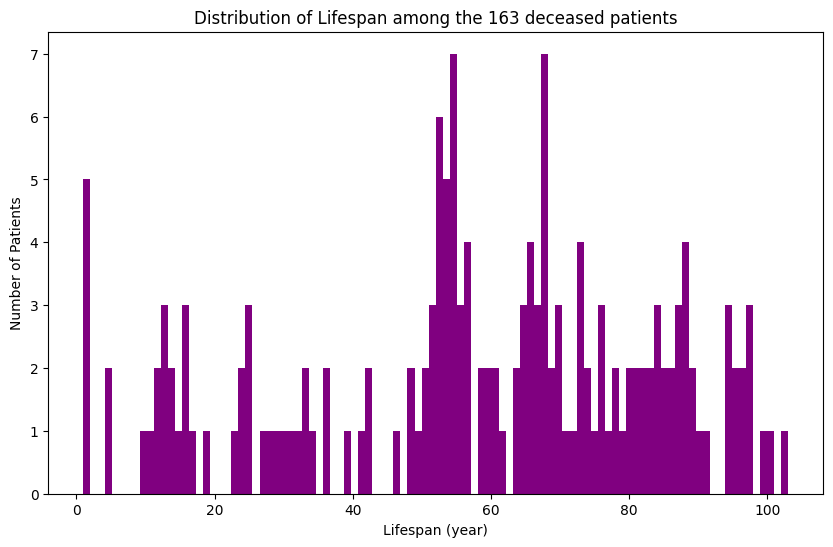

In [379]:
plt.figure(figsize=(10, 6))
plt.hist(synthea_1k_patients_lifespan_series, bins=100, color='purple')
plt.title('Distribution of Lifespan among the 163 deceased patients')
plt.xlabel('Lifespan (year)')
plt.ylabel('Number of Patients')

# Show the plot
plt.grid(False)
plt.show()

#### Plot the distribution of age of the alive patients

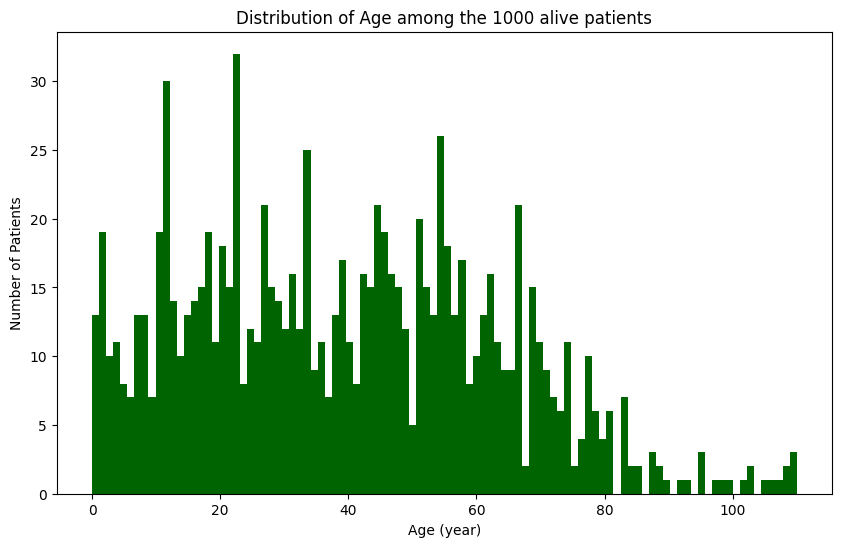

In [380]:
plt.figure(figsize=(10, 6))
plt.hist(synthea_1k_patients_age_series, bins=100, color='darkgreen')
plt.title('Distribution of Age among the 1000 alive patients')
plt.xlabel('Age (year)')
plt.ylabel('Number of Patients')

# Show the plot
plt.grid(False)
plt.show()

#### Finally, create a more simplified and structured patient dataframe to be concatenable with other sheets of the EHRs

##### take the useful columns

In [7]:
PRELIMINARY_USEFUL_PATIENT_COLUMNS = \
['Id',
 'RACE',
 #'ETHNICITY', ## we shall not use the "non-Hispanic" and "Hispanic" dichotomy since they are overgeneralized labels used only in the US?
 'GENDER',
 #'BIRTHPLACE', ## replaced with the country of birth
 'STATE',
 'HEALTHCARE_EXPENSES',
 'HEALTHCARE_COVERAGE']

##### Create a <code>pandas.Series</code> to represent the country of birth of each patient

In [9]:
BIRTH_COUNTRY_LIST = list(synthea_1k_patients_df.BIRTHPLACE.apply(lambda x: x.split("  ")[2]))
synthea_1k_patients_birth_country_series = pd.Series(BIRTH_COUNTRY_LIST, dtype="category")

In [10]:
synthea_1k_patients_birth_country_series

0       US
1       US
2       GR
3       US
4       US
        ..
1158    US
1159    US
1160    US
1161    US
1162    US
Length: 1163, dtype: category
Categories (25, object): ['AR', 'CN', 'CO', 'CU', ..., 'RU', 'SA', 'US', 'VN']

##### Name the refactored dataframe of patients as <code>synthea_1k_patients_refactored</code>

In [11]:
synthea_1k_patients_refactored = synthea_1k_patients_df[PRELIMINARY_USEFUL_PATIENT_COLUMNS].copy()

Fill the extra columns with the series created above

In [28]:
synthea_1k_patients_refactored["VITAL_STATUS"] = synthea_1k_patients_alive_series
synthea_1k_patients_refactored["LIFESPAN"] = synthea_1k_patients_lifespan_series
synthea_1k_patients_refactored["AGE"] = synthea_1k_patients_age_series
synthea_1k_patients_refactored["BIRTH_COUNTRY"] = synthea_1k_patients_birth_country_series

In [397]:
synthea_1k_patients_refactored[:20]

,Id,RACE,GENDER,STATE,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,VITAL_STATUS,LIFESPAN,AGE,BIRTH_COUNTRY
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,white,M,Massachusetts,9.039165e+03,7964.1255,True,NaN,3,US
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,white,F,Massachusetts,4.027234e+05,14064.1350,True,NaN,16,US
2,339144f8-50e1-633e-a013-f361391c4cff,white,M,Massachusetts,5.719359e+05,787.5375,True,NaN,24,GR
3,d488232e-bf14-4bed-08c0-a82f34b6a197,white,F,Massachusetts,5.825578e+05,104782.2070,True,NaN,19,US
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,black,M,Massachusetts,4.758269e+05,18067.0950,True,NaN,28,US
5,faac724a-a9e9-be66-fe1e-3044dc0ba8ea,white,F,Massachusetts,3.146804e+04,206.2200,True,NaN,1,US
6,23d16ee3-8cd4-eeb8-e77e-1e5fbf4c4159,black,M,Massachusetts,7.723627e+05,2213.0850,True,NaN,31,CO
7,aade3c61-92bd-d079-9d28-0b2b7fde0fbb,white,M,Massachusetts,9.249573e+05,874.3725,True,NaN,36,US
8,0288c42c-43a1-9878-4a9d-6b96caa12c40,white,F,Massachusetts,1.134818e+06,226909.9595,True,NaN,42,US
9,dc6c06d0-a7d8-100f-c08b-46c93700c188,white,M,Massachusetts,3.906756e+05,1826.3325,True,NaN,15,US


In [29]:
synthea_1k_patients_refactored.dtypes

Id                       object
RACE                     object
GENDER                   object
STATE                    object
HEALTHCARE_EXPENSES     float64
HEALTHCARE_COVERAGE     float64
VITAL_STATUS            boolean
LIFESPAN               category
AGE                    category
BIRTH_COUNTRY          category
dtype: object

refactor all the non-id and non-numerical datatypes into category

In [30]:
synthea_1k_patients_refactored["RACE"] = synthea_1k_patients_refactored["RACE"].astype("category")
synthea_1k_patients_refactored["GENDER"] = synthea_1k_patients_refactored["GENDER"].astype("category")
synthea_1k_patients_refactored["STATE"] = synthea_1k_patients_refactored["STATE"].astype("category")

In [31]:
synthea_1k_patients_refactored.dtypes

Id                       object
RACE                   category
GENDER                 category
STATE                  category
HEALTHCARE_EXPENSES     float64
HEALTHCARE_COVERAGE     float64
VITAL_STATUS            boolean
LIFESPAN               category
AGE                    category
BIRTH_COUNTRY          category
dtype: object

### Then, investigate the other potentially informative sheets
We think that
```bash
conditions.csv
devices.csv
encounters.csv
medications.csv
observations.csv
immunizations.csv
```
for the use of further imputation analysis since they might consist of informative non-administrative data

#### The "Devices" sheet (not used further)

In [108]:
synthea_1k_devices_df = pd.read_csv("Synthea_data/synthea_sample_data_csv_1K_nov2021/devices.csv")
synthea_1k_devices_df.dtypes

START          object
STOP           object
PATIENT        object
ENCOUNTER      object
CODE            int64
DESCRIPTION    object
UDI            object
dtype: object

In [109]:
synthea_1k_devices_df.shape

(89, 7)

In [110]:
synthea_1k_devices_df.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,UDI
0,2017-09-25T17:26:19Z,NaN,d1822991-eb4f-aafe-6a88-cd5279b4385b,bd2f33cd-4a24-6e32-1cd2-bf075ba9ed77,72506001,Implantable defibrillator device (physical ob...,(01)32224845419831(11)170904(17)420919(10)7079...
1,1987-09-21T02:27:51Z,NaN,04f25f73-04b2-469c-3806-540417a0d61c,807a0ee3-a9b1-30e1-3b19-bc2bddf952e8,72506001,Implantable defibrillator device (physical ob...,(01)84789768157847(11)870830(17)120913(10)3106...
2,2015-07-12T12:58:53Z,NaN,e000e5c8-30f7-7a53-a324-7f3e431ba008,5dfe5aec-2194-02ba-e4db-d16b42d28338,72506001,Implantable defibrillator device (physical ob...,(01)87802513365737(11)150621(17)400705(10)2864...
3,1983-07-18T16:34:31Z,NaN,89464607-f8af-06a3-fe2f-227495c12550,ea2d35e3-1cca-d560-f8ee-21bcfd480a9c,72506001,Implantable defibrillator device (physical ob...,(01)71493530635894(11)830627(17)080711(10)6970...
4,2008-04-04T12:43:40Z,NaN,ff0e4d0e-6181-e36e-d817-64dbcaecb5d0,9ac93727-a73c-5479-6d06-35999c01756d,705643001,Coronary artery stent (physical object),(01)60616412587042(11)080314(17)330329(10)1877...


In [111]:
synthea_1k_devices_df.iloc[0]['CODE']

72506001

From <a>http://purl.bioontology.org/ontology/SNOMEDCT/72506001</a>, we could see that the column <code>synthea_1k_devices_df["CODE"]</code> refers to SNOMED-CT codes

<b>Conclusions</b>: the variety of medical devices applied on the patients is not particularly of our interest in imputation for missing data in EHRs, therefore, we wouldn't like to include this dataframe into our work

In [112]:
synthea_1k_devices_df = None # delete this pointer from the memory

#### The "Conditions" sheet (to be used)

##### Take a look at its metadata

In [32]:
synthea_1k_conditions_df = pd.read_csv("Synthea_data/synthea_sample_data_csv_1K_nov2021/conditions.csv")
synthea_1k_conditions_df.dtypes

START          object
STOP           object
PATIENT        object
ENCOUNTER      object
CODE            int64
DESCRIPTION    object
dtype: object

In [33]:
synthea_1k_conditions_df.shape

(38094, 6)

##### Refactor this dataframe a bit

In [34]:
synthea_1k_conditions_df['CODE'] = synthea_1k_conditions_df['CODE'].astype("category")

In [35]:
synthea_1k_conditions_df.dtypes

START            object
STOP             object
PATIENT          object
ENCOUNTER        object
CODE           category
DESCRIPTION      object
dtype: object

##### Take a look at its actual data

In [36]:
synthea_1k_conditions_df.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2013-06-24,2013-07-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,0b2794bd-ec2b-d34f-0610-2523b3b7fcf0,10509002,Acute bronchitis (disorder)
1,2016-02-27,2016-03-14,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,a6d818dd-0983-fd1c-eefa-3d2295532c45,283371005,Laceration of forearm
2,2016-08-11,2016-08-22,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,36d2e781-4655-0a11-1f70-c69856e02019,444814009,Viral sinusitis (disorder)
3,2016-11-27,2016-12-17,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,c8eaaf41-958b-31ab-7de5-568cee8751f3,444814009,Viral sinusitis (disorder)
4,2017-02-22,2017-06-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,6474f606-5a1b-48c0-bbbf-ad6dcbc24d4e,16114001,Fracture of ankle


In [37]:
synthea_1k_conditions_df.iloc[0]['CODE'] 

10509002

##### How should I concatenate this dataframe with the refactored Patient Dataframe?

From <a>http://purl.bioontology.org/ontology/SNOMEDCT/10509002</a>, we could see that the column synthea_1k_columns_df["CODE"] refers to SNOMED-CT codes

In [38]:
synthea_1k_patients_df[synthea_1k_patients_df['Id'] == str(synthea_1k_conditions_df.iloc[0]['PATIENT'])]

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,...,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,NaN,999-49-3323,S99941126,NaN,NaN,Thi53,Wunsch504,NaN,...,Danvers Massachusetts US,972 Tillman Branch Suite 48,Bellingham,Massachusetts,Norfolk County,NaN,42.035213,-71.482519,402723.415,14064.135


Conclusion：the field <code>synthea_1k_patients_df['id']</code> would be useful for concatenation with other dataframes

<b>Conclusions</b>: the variety of clinical conditions of the patients coded by SNOMED-CT is particularly of our interest in imputation for missing data in EHRs, therefore, we wouldn like to include this dataframe into our work

Let's create a Python dictionary of SNOMED-CT code terms describing the clinical conditions, using <code>synthea_1k_conditions_df["CODE"]</code> as the keys and <code>synthea_1k_conditions_df["DESCRIPTION"]</code> as the columns

##### Visualize the statistics of the conditions

###### Create a dictionary of the conditions

In [39]:
CONDITIONS_SNOMED_CT_DICT: Dict[Any, Any] = {}

In [40]:
def add_new_dict_terms(ref_dict: Dict[Any, Any], new_key: str, new_value: Any):
    if new_key not in ref_dict:
        ref_dict[new_key] = new_value

In [41]:
synthea_1k_conditions_df[["CODE", "DESCRIPTION"]].apply(lambda x: add_new_dict_terms(CONDITIONS_SNOMED_CT_DICT, x["CODE"], x["DESCRIPTION"]), 
                                                        axis=1)

0        None
1        None
2        None
3        None
4        None
         ... 
38089    None
38090    None
38091    None
38092    None
38093    None
Length: 38094, dtype: object

In [43]:
len(CONDITIONS_SNOMED_CT_DICT.items())

202

In [44]:
list(CONDITIONS_SNOMED_CT_DICT.items())[:5]

[(10509002, 'Acute bronchitis (disorder)'),
 (283371005, 'Laceration of forearm'),
 (444814009, 'Viral sinusitis (disorder)'),
 (16114001, 'Fracture of ankle'),
 (44465007, 'Sprain of ankle')]

###### Count the prevalance of each condition among the alive/deceased patients

In [46]:
condition_occurences_per_patient = synthea_1k_conditions_df.groupby(["CODE", "PATIENT"], observed=True).size().reset_index(name="COUNT")
condition_occurences_per_patient

,CODE,PATIENT,COUNT
0,1734006,d3e4ad8c-11f2-14cf-28be-e4400b6caff1,1
1,5602001,219ddc63-11fe-e940-aa69-0e1bdd131e08,1
2,5602001,396babc6-6b4f-e29b-40f7-ea119ee57ac4,1
3,5602001,418c6a4c-1615-cba9-80b3-ac2901f4c07f,1
4,5602001,442970b2-2f69-0f03-b394-96221a5a3ee6,1
...,...,...,...
15549,10939881000119104,fa2d28b1-de84-ac96-ee04-a20dc54832c1,1
15550,10939881000119104,fa311677-035c-7329-3dec-2a01c9afd965,1
15551,10939881000119104,fc3aa467-2e84-d473-50cc-d6aefa6bd94b,3
15552,10939881000119104,fca626fd-ab99-57fb-ba8d-f0bad053788b,1


In [47]:
condition_occurences = condition_occurences_per_patient.groupby(["CODE"], observed=True).size().reset_index(name="NUM_PATIENTS")
condition_occurences

,CODE,NUM_PATIENTS
0,1734006,1
1,5602001,11
2,6072007,6
3,7200002,7
4,10509002,454
...,...,...
197,97331000119101,4
198,124171000119105,45
199,132281000119108,6
200,368581000119106,24


Sort the dataframe by the frequency of occurences among all patients in descending order

In [48]:
condition_occurences = condition_occurences.sort_values(by="NUM_PATIENTS", ascending=False).reset_index(drop=True)

In [49]:
condition_occurences

,CODE,NUM_PATIENTS
0,73595000,894
1,160903007,834
2,444814009,739
3,160904001,686
4,423315002,661
...,...,...
197,45816000,1
198,431856006,1
199,370143000,1
200,86175003,1


Look at the names of the top 10 conditions

In [50]:
top_ten_conditions_dict: Dict[str, float] = dict()

for code in list(condition_occurences["CODE"].iloc[0:10]):
    top_ten_conditions_dict[CONDITIONS_SNOMED_CT_DICT[code]] = \
    "".join([
    format(
        int(condition_occurences["NUM_PATIENTS"][condition_occurences["CODE"]==code].iloc[0])/synthea_1k_patients_refactored.shape[0] * 100,
        ".2f"
    ), "%"
    ])
top_ten_conditions_dict

{'Stress (finding)': '76.87%',
 'Full-time employment (finding)': '71.71%',
 'Viral sinusitis (disorder)': '63.54%',
 'Part-time employment (finding)': '58.99%',
 'Limited social contact (finding)': '56.84%',
 'Social isolation (finding)': '56.15%',
 'Received higher education (finding)': '44.97%',
 'Acute viral pharyngitis (disorder)': '43.51%',
 'Not in labor force (finding)': '43.08%',
 'Victim of intimate partner abuse (finding)': '40.07%'}

<b>Conclusions</b>: we could observe that, majority of the SNOMED-coded conditions are psychogenic ones, with only two being physical diseases. <br>
Therefore, we have to differentiate the conditions of psychogenic and physical diseases, which cannot be done with this sheet only 

#### The "Encounters" sheet (unsure whether to be used)

##### Take a look at its metadata

In [122]:
synthea_1k_encounters_df = pd.read_csv("Synthea_data/synthea_sample_data_csv_1K_nov2021/encounters.csv")
synthea_1k_encounters_df.dtypes

Id                      object
START                   object
STOP                    object
PATIENT                 object
ORGANIZATION            object
PROVIDER                object
PAYER                   object
ENCOUNTERCLASS          object
CODE                     int64
DESCRIPTION             object
BASE_ENCOUNTER_COST    float64
TOTAL_CLAIM_COST       float64
PAYER_COVERAGE         float64
REASONCODE             float64
REASONDESCRIPTION       object
dtype: object

In [123]:
synthea_1k_encounters_df.shape

(61459, 15)

##### Refactor this dataframe a bit

In [124]:
synthea_1k_encounters_df["REASONCODE"].loc[synthea_1k_encounters_df.REASONCODE.notna()]

13        10509002.0
20       444814009.0
21       444814009.0
23        16114001.0
38        59621000.0
            ...     
61449     62564004.0
61450     55822004.0
61452     55822004.0
61454     55822004.0
61455     38822007.0
Name: REASONCODE, Length: 15957, dtype: float64

In [125]:
synthea_1k_encounters_df["CODE"] = synthea_1k_encounters_df["CODE"].astype("category")
synthea_1k_encounters_df["REASONCODE"] = synthea_1k_encounters_df["REASONCODE"].astype("category")

In [153]:
synthea_1k_encounters_df["CODE"]

0        410620009
1        410620009
2        410620009
3        410620009
4        410620009
           ...    
61454    390906007
61455    185345009
61456    162673000
61457     33879002
61458     33879002
Name: CODE, Length: 61459, dtype: category
Categories (50, int64): [1505002, 1853470, 22298006, 32485007, ..., 439740005, 448337001, 698314001, 702927004]

In [126]:
synthea_1k_encounters_df.loc[synthea_1k_encounters_df["REASONCODE"].notna(), "REASONCODE"]

13        10509002.0
20       444814009.0
21       444814009.0
23        16114001.0
38        59621000.0
            ...     
61449     62564004.0
61450     55822004.0
61452     55822004.0
61454     55822004.0
61455     38822007.0
Name: REASONCODE, Length: 15957, dtype: category
Categories (104, float64): [1734006.0, 5602001.0, 6072007.0, 10509002.0, ..., 1.121000e+12, 1.241710e+14, 3.685810e+14, 1.093988e+16]

From <a>http://purl.bioontology.org/ontology/SNOMEDCT/10509002</a>, we could see that the column synthea_1k_encounters_df["REASONCODE"] refers to SNOMED-CT codes

In [150]:
synthea_1k_encounters_df.dtypes

Id                       object
START                    object
STOP                     object
PATIENT                  object
ORGANIZATION             object
PROVIDER                 object
PAYER                    object
ENCOUNTERCLASS           object
CODE                   category
DESCRIPTION              object
BASE_ENCOUNTER_COST     float64
TOTAL_CLAIM_COST        float64
PAYER_COVERAGE          float64
REASONCODE             category
REASONDESCRIPTION        object
dtype: object

##### Take a look at its actual data

In [127]:
synthea_1k_encounters_df.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,748f8357-6cc7-551d-f31a-32fa2cf84126,2019-02-17T05:07:38Z,2019-02-17T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,877.79,833.90,NaN,NaN
1,5a4735ae-423f-6563-28ab-b3d11b49b2d4,2019-03-24T05:07:38Z,2019-03-24T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,269.68,256.20,NaN,NaN
2,0bee1ce6-3e2c-5506-f71c-a7ba8f64a3d3,2019-05-26T05:07:38Z,2019-05-26T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,1292.75,1228.11,NaN,NaN
3,6e93bcf9-45a4-8528-0120-1c1eaa930faf,2019-07-28T05:07:38Z,2019-07-28T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,1323.87,1257.68,NaN,NaN
4,8b6787c3-4316-a0cb-899d-4746525c319f,2019-10-27T05:07:38Z,2019-10-27T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,831.76,790.17,NaN,NaN


From <a>http://purl.bioontology.org/ontology/SNOMEDCT/410620009</a>, we could see that the column synthea_1k_encounters_df["CODE"] refers to SNOMED-CT codes

In [128]:
synthea_1k_encounters_df.describe()

,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE
count,61459.000000,61459.000000,61459.000000
mean,113.262767,4149.657952,1033.709602
std,23.847374,10919.677889,4902.646135
min,77.490000,0.000000,0.000000
25%,77.490000,129.160000,0.000000
50%,129.160000,786.330000,0.000000
75%,129.160000,1625.890000,29.990000
max,129.160000,873646.190000,227851.810000


Take a look at the rows where the reason code was not null

In [129]:
synthea_1k_encounters_df[["REASONCODE", "REASONDESCRIPTION"]].loc[synthea_1k_encounters_df.REASONCODE.notna()].shape

(15957, 2)

In [138]:
synthea_1k_encounters_df.dtypes

Id                       object
START                    object
STOP                     object
PATIENT                  object
ORGANIZATION             object
PROVIDER                 object
PAYER                    object
ENCOUNTERCLASS           object
CODE                   category
DESCRIPTION              object
BASE_ENCOUNTER_COST     float64
TOTAL_CLAIM_COST        float64
PAYER_COVERAGE          float64
REASONCODE             category
REASONDESCRIPTION        object
dtype: object

<b>Conclusions:</b> there are 15957 encounters due to physical diseases out of the 61459 diseases in total

<b>Question</b>: Does it make sense to exclude the psychogenic conditions and encounters, as well as the patients with only psychogenic conditions from our dataset for training?

#### The "Medications" sheet (unsure whether to be used)

##### Take a look at its metadata

In [132]:
synthea_1k_medications_df = pd.read_csv("Synthea_data/synthea_sample_data_csv_1K_nov2021/medications.csv")
synthea_1k_medications_df.dtypes

START                 object
STOP                  object
PATIENT               object
PAYER                 object
ENCOUNTER             object
CODE                   int64
DESCRIPTION           object
BASE_COST            float64
PAYER_COVERAGE       float64
DISPENSES              int64
TOTALCOST            float64
REASONCODE           float64
REASONDESCRIPTION     object
dtype: object

In [154]:
synthea_1k_medications_df.shape

(56430, 13)

##### Refactor the dataframe a bit

In [133]:
synthea_1k_medications_df.CODE = synthea_1k_medications_df.CODE.astype("category")
synthea_1k_medications_df.REASONCODE = synthea_1k_medications_df.REASONCODE.astype("category")

##### Take a look at the actual data

In [134]:
synthea_1k_medications_df.head()

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2020-02-17T10:40:32Z,NaN,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,01efcc52-15d6-51e9-faa2-bee069fcbe44,1014676,cetirizine hydrochloride 5 MG Oral Tablet,21.45,0.0,21,450.45,NaN,NaN
1,2020-02-17T10:40:32Z,NaN,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,01efcc52-15d6-51e9-faa2-bee069fcbe44,1870230,NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Inje...,231.58,0.0,21,4863.18,NaN,NaN
2,2013-06-24T06:39:19Z,2013-07-02T06:39:19Z,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,0b2794bd-ec2b-d34f-0610-2523b3b7fcf0,1043400,Acetaminophen 21.7 MG/ML / Dextromethorphan Hy...,7.59,0.0,1,7.59,10509002.0,Acute bronchitis (disorder)
3,2016-02-27T08:52:29Z,2016-03-14T08:52:29Z,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,6e2f1a2d-27bd-3701-8d08-dae202c58632,a6d818dd-0983-fd1c-eefa-3d2295532c45,198405,Ibuprofen 100 MG Oral Tablet,12.48,0.0,1,12.48,NaN,NaN
4,2017-02-22T09:25:31Z,2017-06-02T09:25:31Z,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,047f6ec3-6215-35eb-9608-f9dda363a44c,6474f606-5a1b-48c0-bbbf-ad6dcbc24d4e,313820,Acetaminophen 160 MG Chewable Tablet,4.77,0.0,3,14.31,NaN,NaN


In [135]:
synthea_1k_medications_df.describe()

,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST
count,56430.000000,56430.000000,56430.000000,5.643000e+04
mean,194.012436,32.706898,82.151763,1.309726e+03
std,737.520319,228.073054,159.634372,2.005578e+04
min,0.010000,0.000000,1.000000,1.000000e-02
25%,0.020000,0.000000,1.000000,4.520000e+00
50%,18.140000,0.000000,12.000000,3.527000e+01
75%,154.757500,0.000000,28.000000,4.787525e+02
max,7011.480000,6546.400000,8469.000000,2.197450e+06


In [137]:
synthea_1k_medications_df.dtypes

START                  object
STOP                   object
PATIENT                object
PAYER                  object
ENCOUNTER              object
CODE                 category
DESCRIPTION            object
BASE_COST             float64
PAYER_COVERAGE        float64
DISPENSES               int64
TOTALCOST             float64
REASONCODE           category
REASONDESCRIPTION      object
dtype: object

##### Explore the columns of partcular interest, such as <code>CODE</code>, <code>DISPENSES</code>, <code>TOTAL_COST</code>, and <code>REASON_CODE</code>

#### The "Observations" sheet (unsure whether to be used)

##### Take a look at its metadata

In [141]:
synthea_1k_observations_df = pd.read_csv("Synthea_data/synthea_sample_data_csv_1K_nov2021/observations.csv")
synthea_1k_observations_df.dtypes

DATE           object
PATIENT        object
ENCOUNTER      object
CATEGORY       object
CODE           object
DESCRIPTION    object
VALUE          object
UNITS          object
TYPE           object
dtype: object

In [155]:
synthea_1k_observations_df.shape

(531144, 9)

##### Refactor the dataframe a bit

In [142]:
synthea_1k_observations_df.CODE = synthea_1k_observations_df.CODE.astype("category")
synthea_1k_observations_df.UNITS = synthea_1k_observations_df.UNITS.astype("category")
synthea_1k_observations_df.TYPE = synthea_1k_observations_df.TYPE.astype("category")

##### Take a look at the actual data

In [143]:
synthea_1k_observations_df.head()

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2019-02-17T05:07:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,748f8357-6cc7-551d-f31a-32fa2cf84126,vital-signs,8302-2,Body Height,51.4,cm,numeric
1,2019-02-17T05:07:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,748f8357-6cc7-551d-f31a-32fa2cf84126,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,1.0,{score},numeric
2,2019-02-17T05:07:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,748f8357-6cc7-551d-f31a-32fa2cf84126,vital-signs,29463-7,Body Weight,3.8,kg,numeric
3,2019-02-17T05:07:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,748f8357-6cc7-551d-f31a-32fa2cf84126,vital-signs,77606-2,Weight-for-length Per age and sex,57.9,%,numeric
4,2019-02-17T05:07:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,748f8357-6cc7-551d-f31a-32fa2cf84126,vital-signs,9843-4,Head Occipital-frontal circumference,34.8,cm,numeric


In [145]:
synthea_1k_observations_df.describe()

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
count,531144,531144,499482,499482,531144,531144,531144,346127,531144
unique,63811,1163,21025,8,234,247,6804,43,2
top,2001-01-09T21:04:17Z,ef167059-cef0-12c4-49db-993ca3a20c01,77c7ccff-dbc5-2ee2-7d48-52f8af2eeb67,survey,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,No,mg/dL,numeric
freq,108,9297,678,218284,14537,14537,63663,53791,331164


In [146]:
synthea_1k_observations_df.dtypes

DATE             object
PATIENT          object
ENCOUNTER        object
CATEGORY         object
CODE           category
DESCRIPTION      object
VALUE            object
UNITS          category
TYPE           category
dtype: object

##### Explore the columns of partcular interest, such as <code>CODE</code>, <code>CATEGORY</code>, <code>VALUE</code>, and <code>TYPE</code>